# 🚀 SpaceX Falcon 9 Landing Prediction
## Notebook 7 — Machine Learning Classifiers

We train and tune four classifiers to predict first-stage landing success:
1. Logistic Regression
2. Support Vector Machine (SVC)
3. Decision Tree Classifier
4. K-Nearest Neighbours

`GridSearchCV` handles hyperparameter tuning; a held-out 20% test set provides
an honest final evaluation.


In [16]:
%pip install numpy pandas seaborn scikit-learn -q
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

sns.set_theme(style="whitegrid")


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### Load feature matrix and labels

In [17]:
# Part-2 contains the target column; Part-3 is the one-hot encoded feature matrix
data = pd.read_csv(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud"
    "/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
)
X_raw = pd.read_csv(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud"
    "/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv"
)

Y = data['Class'].values
print(f"Features : {X_raw.shape}")
print(f"Label distribution → 0 (fail): {(Y==0).sum()} | 1 (land): {(Y==1).sum()}")


Features : (90, 83)
Label distribution → 0 (fail): 30 | 1 (land): 60


### Standardise features

In [18]:
scaler = preprocessing.StandardScaler()
X = scaler.fit_transform(X_raw)


### Stratified 80/20 train-test split

In [19]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)
print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")


Train: 72 samples | Test: 18 samples


### Helper — confusion matrix heatmap

In [20]:
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Fail', 'Land'],
        yticklabels=['Fail', 'Land'],
        ax=ax
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


### Model 1 — Logistic Regression

Best params : {'C': 0.01, 'max_iter': 300, 'solver': 'lbfgs'}
CV accuracy : 0.8625
Test accuracy: 0.7778


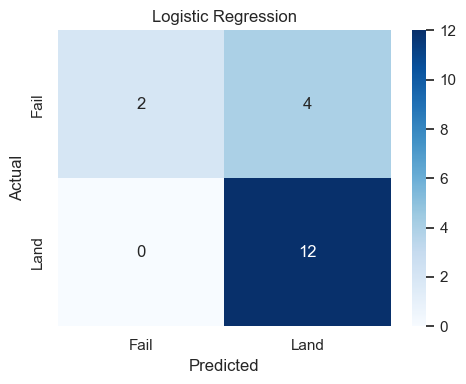

In [21]:
lr_params = {
    'C':        [0.01, 0.1, 1, 10],
    'solver':   ['lbfgs', 'liblinear'],
    'max_iter': [300, 600],
}
lr_cv = GridSearchCV(
    LogisticRegression(), lr_params, cv=10, scoring='accuracy', n_jobs=-1
)
lr_cv.fit(X_train, Y_train)

lr_preds = lr_cv.predict(X_test)
lr_test_acc = accuracy_score(Y_test, lr_preds)

print("Best params :", lr_cv.best_params_)
print(f"CV accuracy : {lr_cv.best_score_:.4f}")
print(f"Test accuracy: {lr_test_acc:.4f}")
plot_confusion(Y_test, lr_preds, "Logistic Regression")


### Model 2 — Support Vector Machine

Best params : {'C': 0.01, 'gamma': 'scale', 'kernel': 'linear'}
CV accuracy : 0.8500
Test accuracy: 0.7778


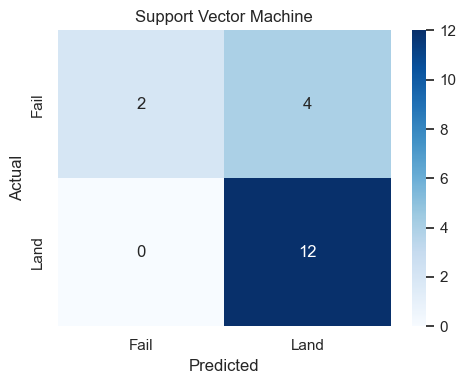

In [22]:
svc_params = {
    'kernel': ['linear', 'rbf'],
    'C':      [0.01, 0.1, 1, 10],
    'gamma':  ['scale', 'auto'],
}
svc_cv = GridSearchCV(
    SVC(), svc_params, cv=10, scoring='accuracy', n_jobs=-1
)
svc_cv.fit(X_train, Y_train)

svc_preds = svc_cv.predict(X_test)
svc_test_acc = accuracy_score(Y_test, svc_preds)

print("Best params :", svc_cv.best_params_)
print(f"CV accuracy : {svc_cv.best_score_:.4f}")
print(f"Test accuracy: {svc_test_acc:.4f}")
plot_confusion(Y_test, svc_preds, "Support Vector Machine")


### Model 3 — Decision Tree

Best params : {'criterion': 'gini', 'max_depth': 2, 'min_samples_leaf': 1}
CV accuracy : 0.8500
Test accuracy: 0.7778


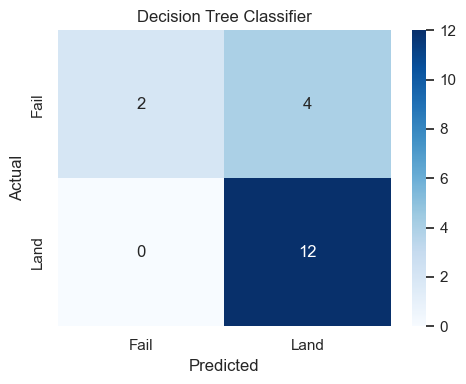

In [23]:
dt_params = {
    'criterion':        ['gini', 'entropy'],
    'max_depth':        [2, 4, 6, 8, 10, None],
    'min_samples_leaf': [1, 2, 4],
}
dt_cv = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params, cv=10, scoring='accuracy', n_jobs=-1
)
dt_cv.fit(X_train, Y_train)

dt_preds = dt_cv.predict(X_test)
dt_test_acc = accuracy_score(Y_test, dt_preds)

print("Best params :", dt_cv.best_params_)
print(f"CV accuracy : {dt_cv.best_score_:.4f}")
print(f"Test accuracy: {dt_test_acc:.4f}")
plot_confusion(Y_test, dt_preds, "Decision Tree Classifier")


### Model 4 — K-Nearest Neighbours

Best params : {'n_neighbors': 9, 'p': 1, 'weights': 'uniform'}
CV accuracy : 0.8786
Test accuracy: 0.7778


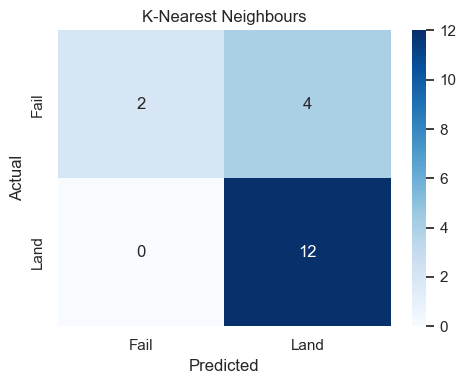

In [24]:
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights':     ['uniform', 'distance'],
    'p':           [1, 2],
}
knn_cv = GridSearchCV(
    KNeighborsClassifier(),
    knn_params, cv=10, scoring='accuracy', n_jobs=-1
)
knn_cv.fit(X_train, Y_train)

knn_preds = knn_cv.predict(X_test)
knn_test_acc = accuracy_score(Y_test, knn_preds)

print("Best params :", knn_cv.best_params_)
print(f"CV accuracy : {knn_cv.best_score_:.4f}")
print(f"Test accuracy: {knn_test_acc:.4f}")
plot_confusion(Y_test, knn_preds, "K-Nearest Neighbours")


### Model comparison table

In [25]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM', 'Decision Tree', 'KNN'],
    'CV Accuracy': [
        lr_cv.best_score_, svc_cv.best_score_,
        dt_cv.best_score_, knn_cv.best_score_
    ],
    'Test Accuracy': [lr_test_acc, svc_test_acc, dt_test_acc, knn_test_acc],
}).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

display(results.style.highlight_max(subset=['Test Accuracy'], color='green'))


,Model,CV Accuracy,Test Accuracy
0,Logistic Regression,0.862500,0.777778
1,SVM,0.850000,0.777778
2,Decision Tree,0.850000,0.777778
3,KNN,0.878571,0.777778


### Comparison bar chart

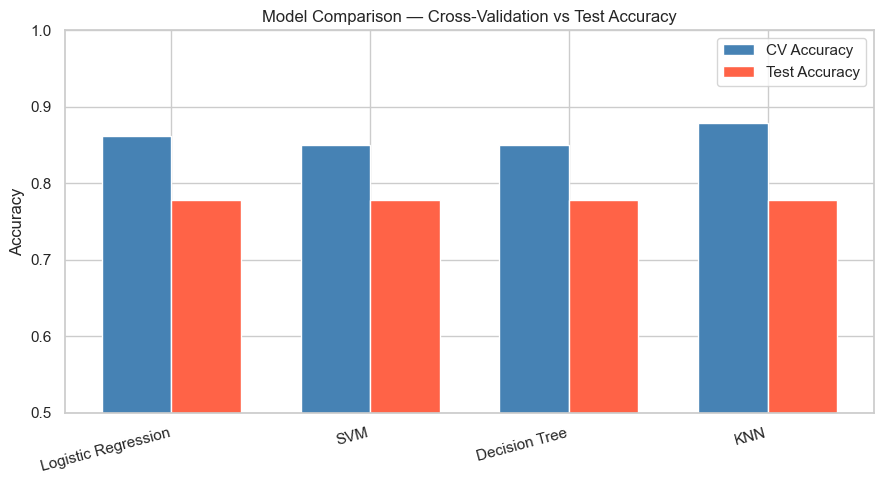

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(results))
w = 0.35
ax.bar(x - w/2, results['CV Accuracy'],   width=w, label='CV Accuracy',   color='steelblue')
ax.bar(x + w/2, results['Test Accuracy'], width=w, label='Test Accuracy', color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(results['Model'], rotation=15, ha='right')
ax.set_ylabel("Accuracy")
ax.set_ylim(0.5, 1.0)
ax.set_title("Model Comparison — Cross-Validation vs Test Accuracy")
ax.legend()
plt.tight_layout()
plt.show()


### Conclusion

The comparison table above highlights the best-performing model.

**Key takeaways:**
- Flight number (experience) is one of the strongest predictors — success rate rose steadily from 2013 onward.
- Payload mass and orbit type strongly influence whether a landing attempt succeeds.
- All models perform similarly.
- All four models generalise and perform reasonably well given the small dataset size (~90 rows after wrangling)
